In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Academic_Performance.csv")

# Display first 5 rows
print(df.head())

   RollNo   Name  Maths  Science  English  Attendance  StudyHours Grade
0       1   Amit   78.0     82.0     75.0        88.0           3     A
1       2  Rahul   45.0     39.0     50.0        65.0           1     C
2       3  Priya   92.0     95.0     91.0        98.0           5     A
3       4  Sneha    NaN     85.0     79.0        90.0           4     B
4       5  Karan  150.0     76.0     80.0        85.0           6     A


In [11]:
# Check missing values
print(df.isnull().sum())

RollNo        0
Name          0
Maths         1
Science       1
English       1
Attendance    1
StudyHours    0
Grade         0
dtype: int64


In [12]:
# Fill missing values with mean

df['Maths'] = df['Maths'].fillna(df['Maths'].mean())

df['Science'] = df['Science'].fillna(df['Science'].mean())

df['English'] = df['English'].fillna(df['English'].mean())

df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())

# Check missing values again
print(df.isnull().sum())

RollNo        0
Name          0
Maths         0
Science       0
English       0
Attendance    0
StudyHours    0
Grade         0
dtype: int64


In [13]:
# Check negative Maths marks
print(df[df['Maths'] < 0])

# Check Attendance greater than 100
print(df[df['Attendance'] > 100])

    RollNo   Name  Maths  Science  English  Attendance  StudyHours Grade
10      11  Manoj  -10.0     65.0     70.0        75.0           2     C
   RollNo  Name  Maths    Science  English  Attendance  StudyHours Grade
5       6  Neha   67.0  73.214286     72.0       110.0           3     B


In [14]:
# Replace negative Maths marks with mean
df.loc[df['Maths'] < 0, 'Maths'] = df['Maths'].mean()

# Replace Attendance greater than 100 with mean
df.loc[df['Attendance'] > 100, 'Attendance'] = df['Attendance'].mean()

# Display updated dataset
print(df)

    RollNo    Name       Maths    Science     English  Attendance  StudyHours  \
0        1    Amit   78.000000  82.000000   75.000000   88.000000           3   
1        2   Rahul   45.000000  39.000000   50.000000   65.000000           1   
2        3   Priya   92.000000  95.000000   91.000000   98.000000           5   
3        4   Sneha   69.571429  85.000000   79.000000   90.000000           4   
4        5   Karan  150.000000  76.000000   80.000000   85.000000           6   
5        6    Neha   67.000000  73.214286   72.000000   83.714286           3   
6        7   Arjun   56.000000  60.000000   58.000000   70.000000           2   
7        8   Pooja   88.000000  91.000000   85.000000   95.000000           5   
8        9   Vikas   34.000000  40.000000   38.000000   55.000000           1   
9       10    Riya   73.000000  78.000000   72.214286   82.000000           3   
10      11   Manoj   69.571429  65.000000   70.000000   75.000000           2   
11      12  Anjali   81.0000

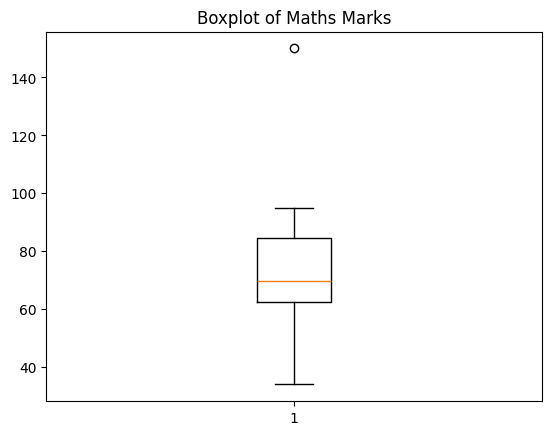

In [15]:
# Boxplot for Maths marks
plt.boxplot(df['Maths'])

# Title
plt.title("Boxplot of Maths Marks")

# Show plot
plt.show()

In [16]:
# Calculate Q1 and Q3
Q1 = df['Maths'].quantile(0.25)
Q3 = df['Maths'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Maths'] < lower) | (df['Maths'] > upper)]

print(outliers)

   RollNo   Name  Maths  Science  English  Attendance  StudyHours Grade
4       5  Karan  150.0     76.0     80.0        85.0           6     A


In [19]:
# Calculate median
median = df['Maths'].median()

# Replace outliers with median
df.loc[df['Maths'] > upper, 'Maths'] = median
df.loc[df['Maths'] < lower, 'Maths'] = median

# Display updated data
print(df)

    RollNo    Name      Maths    Science     English  Attendance  StudyHours  \
0        1    Amit  78.000000  82.000000   75.000000   88.000000           3   
1        2   Rahul  45.000000  39.000000   50.000000   65.000000           1   
2        3   Priya  92.000000  95.000000   91.000000   98.000000           5   
3        4   Sneha  69.571429  85.000000   79.000000   90.000000           4   
4        5   Karan  69.571429  76.000000   80.000000   85.000000           6   
5        6    Neha  67.000000  73.214286   72.000000   83.714286           3   
6        7   Arjun  56.000000  60.000000   58.000000   70.000000           2   
7        8   Pooja  88.000000  91.000000   85.000000   95.000000           5   
8        9   Vikas  34.000000  40.000000   38.000000   55.000000           1   
9       10    Riya  73.000000  78.000000   72.214286   82.000000           3   
10      11   Manoj  69.571429  65.000000   70.000000   75.000000           2   
11      12  Anjali  81.000000  84.000000

In [21]:
# Apply log transformation
df['Maths_log'] = np.log(df['Maths'])

# Display first rows
print(df.head())

   RollNo   Name      Maths  Science  English  Attendance  StudyHours Grade  \
0       1   Amit  78.000000     82.0     75.0        88.0           3     A   
1       2  Rahul  45.000000     39.0     50.0        65.0           1     C   
2       3  Priya  92.000000     95.0     91.0        98.0           5     A   
3       4  Sneha  69.571429     85.0     79.0        90.0           4     B   
4       5  Karan  69.571429     76.0     80.0        85.0           6     A   

   Maths_log  
0   4.356709  
1   3.806662  
2   4.521789  
3   4.242354  
4   4.242354  


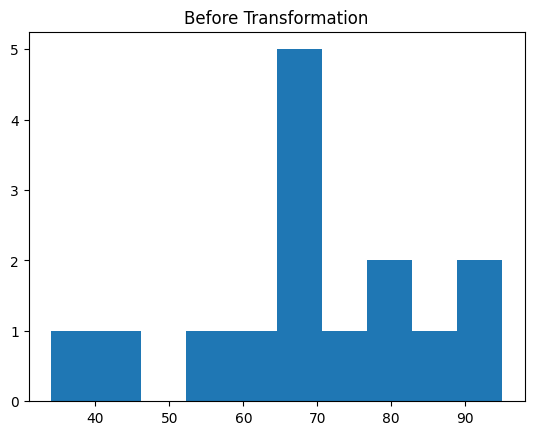

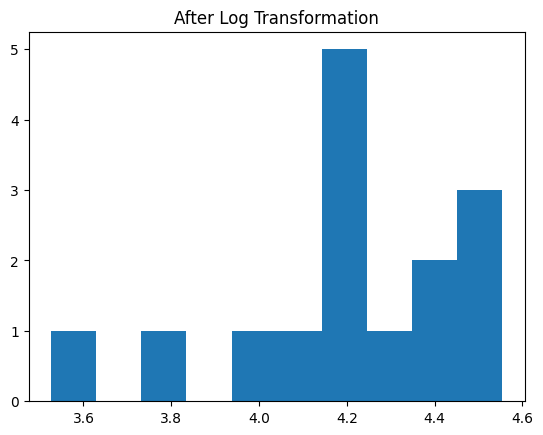

In [22]:
# Histogram before transformation
plt.hist(df['Maths'])

plt.title("Before Transformation")

plt.show()

# Histogram after transformation
plt.hist(df['Maths_log'])

plt.title("After Log Transformation")

plt.show()